In [108]:
from mpmath import coulombf, coulombg
import numpy as np
import mpmath
import numba
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.special import genlaguerre, gamma
from scipy.integrate import quad
from scipy.constants import hbar
# 设置高精度计算（50位小数）
mpmath.mp.dps = 50
# # 计算 F 和 G
# F_values = [mpmath.coulombf(l, eta, rho) for rho in rho_values]
# G_values = [mpmath.coulombg(l, eta, rho) for rho in rho_values]

### system info ###

In [109]:
e2=1.43997 ; hbarc=197.3269718 ; amu=931.49432
z1=86 ; m1=211*amu+-8.755330
z2=2 ; m2=4*amu+2.42491587
Q=8.8624
mu=m1*m2/(m1+m2)
v0=162.08663910042225 ; a0=0.4 ; r0=7.660; l=5; P0=0.03
rc=r0
k=np.sqrt(2*mu*Q/(hbarc**2))
eta= z1 * z2 * e2 * mu / (hbarc**2 * k)
# z1=1 ; m1=1.0078*amu
# z2=0 ; m2=1.0087*amu
# l=0
# mu=m1*m2/(m1+m2)

### v=vn+vc without centrifugal barrier term  ###

In [110]:
#potential function
@numba.njit
def wspot(r,v0,a0,r0):
    return -v0*(1+np.cosh(r0/a0))/(np.cosh(r/a0)+np.cosh(r0/a0))

@numba.njit
def vc(r,z1,z2,rc):
    return np.where(
        r < rc,
        z1 * z2 * e2 * (3 - r**2 / rc**2) /(2 * rc),
        z1 * z2 * e2 / r
    )
    
@numba.njit
def vpot(r,v0,a0,r0,z1,z2,rc,l):
    return wspot(r,v0,a0,r0)+vc(r,z1,z2,rc)

def gausspot(r):
    return -72.15*np.exp(-r**2/1.484**2)

### 3d isotropic hobasis, simplely select $\alpha=\frac{\mu\omega}{\hbar}=1$ ###

In [111]:
def isotropic_ho_radial(n, l, r, alpha=1.0):
    # 计算归一化常数
    norm = np.sqrt(2 * alpha**(3/2) * gamma(n+1) / gamma(n + l + 3/2))
    
    # 计算径向部分
    xi = alpha * r**2
    laguerre = genlaguerre(n, l + 0.5)(xi)
    
    # 组合所有部分
    radial_wave = norm * (alpha**0.5 * r)**l * np.exp(-xi/2) * laguerre
    
    return radial_wave

# r*R_nl(r)
def phi_basis(n, l, r, alpha=1.0):
    
    return r * isotropic_ho_radial(n, l, r, alpha)

### mesh ###

In [112]:
h=0.01
r = np.arange(1e-11, 40, h)

### 2nd derivative of basis at mesh ###

In [113]:
def phi_basis_second_derivative(n, l, r, alpha=1.0, dr=h):
    """
    计算φ_{nl}(r)对r的二阶导数
    内部点使用五点中心差分法
    边界点仅使用phi数组中的值计算
    """
    phi = phi_basis(n, l, r, alpha)
    
    d2phi = np.zeros_like(phi)
    
    # 内部点使用五点中心差分法
    d2phi[2:-2] = (-phi[4:] + 16*phi[3:-1] - 30*phi[2:-2] 
                   + 16*phi[1:-3] - phi[:-4]) / (12*dr**2)
    
    # 边界点简单使用三点差分法（仅用phi数组）
    d2phi[0] = (phi[0] - 2*phi[1] + phi[2]) / (dr**2)  
    d2phi[1] = (phi[0] - 2*phi[1] + phi[2]) / (dr**2)  
    
    d2phi[-1] = (phi[-3] - 2*phi[-2] + phi[-1]) / (dr**2)  
    d2phi[-2] = (phi[-3] - 2*phi[-2] + phi[-1]) / (dr**2)  
    
    return d2phi

### Hamiltonian ###

In [114]:
ndim = 50
H = np.zeros((ndim, ndim), dtype=np.complex128)


for i in range(ndim):
    for j in range(ndim):
        phi_i = phi_basis(i, l, r, alpha=0.5)
        phi_j = phi_basis(j, l, r, alpha=0.5)
        d2phi_j = phi_basis_second_derivative(j, l, r, alpha=0.5, dr=h)
        kinetic_term = (-hbarc**2/2/mu) * simpson(phi_i.conj() * d2phi_j , r)
        centrifugal_term = (hbarc**2/2/mu)*l * (l + 1) * simpson(phi_i.conj() * phi_j / r**2 , r)
        vpot_term = simpson(phi_i.conj() * vpot(r,v0,a0,r0,z1,z2,rc,l)*phi_j,r)
        H[i, j]=kinetic_term+vpot_term+centrifugal_term
        

C:\Users\16437\AppData\Local\Temp\ipykernel_71112\531566525.py:10: DeprecationWarning: You are passing x=[1.000e-11 1.000e-02 2.000e-02 ... 3.997e+01 3.998e+01 3.999e+01] as a positional argument. Please change your invocation to use keyword arguments. From SciPy 1.14, passing these as positional arguments will result in an error.
  kinetic_term = (-hbarc**2/2/mu) * simpson(phi_i.conj() * d2phi_j , r)
C:\Users\16437\AppData\Local\Temp\ipykernel_71112\531566525.py:11: DeprecationWarning: You are passing x=[1.000e-11 1.000e-02 2.000e-02 ... 3.997e+01 3.998e+01 3.999e+01] as a positional argument. Please change your invocation to use keyword arguments. From SciPy 1.14, passing these as positional arguments will result in an error.
  centrifugal_term = (hbarc**2/2/mu)*l * (l + 1) * simpson(phi_i.conj() * phi_j / r**2 , r)
C:\Users\16437\AppData\Local\Temp\ipykernel_71112\531566525.py:12: DeprecationWarning: You are passing x=[1.000e-11 1.000e-02 2.000e-02 ... 3.997e+01 3.998e+01 3.999e+01]

### eigenvalue ###

In [118]:
from scipy.linalg import eigh

# 计算特征值和特征向量
eigenvalues, eigenvectors = eigh(H)

print("最小正特征值:") 
# 找到最小正特征值及其对应的特征向量
min_positive_eigenvalue = min([ev for ev in eigenvalues if ev > 0])
min_index = np.where(eigenvalues == min_positive_eigenvalue)[0][0]
eigenvector = eigenvectors[:, min_index]
print(min_positive_eigenvalue)

最小正特征值:
8.70393400704998


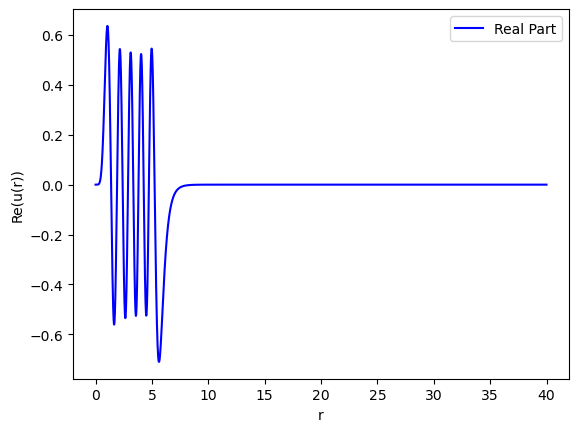

In [116]:
wf = np.zeros_like(r, dtype=np.complex128)
for n in range(len(eigenvector)):  # 遍历所有量子数n
    phi = phi_basis(n, l, r, alpha=1.0)  # 固定l值，只变化n
    wf += eigenvector[n] * phi  # 线性组合

plt.plot(r,wf.real,'b-',label='Real Part')
plt.xlabel('r')
plt.ylabel('Re(u(r))')
plt.legend()
